# Notebook 15 — Mini Assessment (Answer Key)
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**This is the fully worked answer key** for the Sprint 4 self-assessment — every
conceptual question answered in full, every coding exercise implemented and executed
against the real Telco Customer Churn dataset (not a toy example), and every short-answer
prompt addressed with reasoning tied back to this sprint's actual findings.

> Where a coding exercise says "a dataset of your choice," the Telco Customer Churn
> dataset (7,043 customers, 21 columns) — the same dataset used throughout Notebooks
> 1-14 — is used, so every answer is grounded in real, previously-verified numbers rather
> than a fresh, unrelated example.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns")


Dataset ready: 7,043 rows, 21 columns


---
## Section A — Conceptual Questions (Answered)


### Q1. What is EDA?

Exploratory Data Analysis (EDA) is the systematic process of investigating a dataset —
its structure, quality, distributions, and relationships — **before** any preprocessing
or model building begins. It answers the question "what is this data, what does it
contain, and what problems exist in it?" using a mix of statistical summaries and
visualizations, rather than jumping straight to modeling on data that hasn't been
understood yet.


### Q2. Why is EDA performed before Machine Learning?

Because a model trained on unexamined data can silently fail in ways that are invisible
until it's too late — training on a disguised missing value, an unnoticed outlier, or a
leaked feature all produce a model that looks fine on paper but performs badly (or
misleadingly well) in reality. EDA is what catches these problems while they're still
cheap to fix. Concretely, in this sprint alone, EDA caught: `TotalCharges` being stored as
text with 11 disguised missing values (Notebook 2-3), 112 genuine multivariate billing
outliers (Notebook 7), and a moderately imbalanced target that would make raw accuracy a
misleading metric (Notebook 10) — none of which `.info()` or a naive model-first approach
would have surfaced on their own.


### Q3. Explain the difference between univariate, bivariate, and multivariate analysis.

- **Univariate** analysis examines ONE variable in isolation — its distribution, center,
  and spread (Notebook 4). Example: the distribution of `tenure` alone.
- **Bivariate** analysis examines the relationship between TWO variables (Notebook 5).
  Example: how `Churn` relates to `Contract`.
- **Multivariate** analysis examines relationships among THREE OR MORE variables together
  (Notebook 6). Example: Notebook 6's finding that `InternetService`'s relationship with
  churn holds even after controlling for `MonthlyCharges` — a question univariate or
  bivariate analysis alone could never answer, since it requires holding a third variable
  constant while examining a relationship.


### Q4. How do you identify missing values in a dataset?

The standard first check is `df.isnull().sum()` (or `df.info()`), but **this sprint's
single most important lesson about missing values is that this check is not sufficient
on its own.** `TotalCharges` reported zero missing values via `.isnull()` because its 11
gaps were stored as blank strings (`""`) in a text-typed column, not true `NaN` — invisible
to standard detection (Notebook 2-3). A complete check also needs to scan for blank or
whitespace-only strings, and any placeholder values (`'NA'`, `'?'`, `'None'`) in
text-typed columns that look numeric.


In [2]:
# Demonstrating both the naive check AND the deeper check, side by side
print("Naive check (misses the real problem):", df['TotalCharges'].isnull().sum())

df_raw = pd.read_csv("telco_churn.csv")   # reload before the type conversion above
print("Deeper check (blank strings)        :", (df_raw['TotalCharges'].str.strip() == '').sum())


Naive check (misses the real problem): 11
Deeper check (blank strings)        : 11


### Q5. How do you identify duplicate records in a dataset?

`df.duplicated()` flags rows that are exact repeats of an earlier row (returning a
boolean Series), and `.sum()` counts them; `df.drop_duplicates()` removes them. It's also
worth checking for duplicates on a specific subset of columns (e.g., just an identifier)
using `df.duplicated(subset=[...])`, since a full-row duplicate check can miss records
that differ only in a truly irrelevant column.


In [3]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate customerID values: {df['customerID'].duplicated().sum()}")


Fully duplicated rows: 0
Duplicate customerID values: 0


### Q6. What is an outlier?

A data point that deviates markedly from the rest of the data — either because it's a
genuinely unusual but real observation, or because something went wrong when it was
recorded (Sprint 4, Notebook 7, Topic 1-2). Critically, an outlier can be **univariate**
(extreme on one variable alone) or **multivariate** (unremarkable on every individual
variable, but unusual in how those variables relate to each other) — this dataset's real
outlier story turned out to be entirely the latter (112 billing-residual outliers, found
via `tenure × MonthlyCharges` vs. actual `TotalCharges`), despite zero univariate outliers
anywhere.


### Q7. Explain the IQR method for outlier detection.

The IQR (Interquartile Range) method uses the middle 50% of the data as the reference for
"normal." $IQR = Q3 - Q1$, and any value below $Q1 - 1.5 \times IQR$ or above
$Q3 + 1.5 \times IQR$ is flagged as an outlier. It's rank-based (not mean/std-based),
which makes it resistant to being thrown off by the very outliers it's trying to detect —
a genuine advantage over the Z-score method on skewed data.


In [4]:
for col in ['tenure', 'MonthlyCharges']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: bounds=({lower:.2f}, {upper:.2f}) -> {len(outliers)} outliers")


tenure: bounds=(-60.00, 124.00) -> 0 outliers
MonthlyCharges: bounds=(-46.02, 171.38) -> 0 outliers


### Q8. What is skewness?

Skewness measures the asymmetry of a distribution. Positive (right) skew means a long
tail of high values pulling the mean above the median; negative (left) skew is the
mirror image; values near zero indicate a roughly symmetric shape. In this dataset,
`TotalCharges` (skew ≈ 0.96) is the only meaningfully skewed numeric feature — `tenure`
and `MonthlyCharges` are both roughly symmetric despite neither being normally
distributed (Notebook 8).


### Q9. What is correlation?

Correlation is a single number, from -1 to +1, summarizing how strongly and in what
direction two numeric variables move together. +1 means perfectly aligned increases, -1
means perfectly opposite movement, and 0 means no linear relationship. In this dataset,
`tenure` and `TotalCharges` show the strongest correlation found anywhere (+0.826,
Notebook 6) — expected, since `TotalCharges` accumulates directly from `tenure` ×
`MonthlyCharges`.


### Q10. Explain the difference between correlation and causation.

Correlation means two variables move together; causation means one variable's change
*directly produces* a change in the other. Correlation alone never proves causation,
because a third, unmeasured factor can drive both variables at once. This sprint hit a
concrete example: `Cabin` being known (in the Titanic mini-challenge, Notebook 14)
correlated strongly with survival (66.7% vs. 30.0%), but a known cabin number doesn't
*cause* survival — it's a proxy for passenger class, which is what actually relates to
survival. Reporting the correlation as if it were causal would have produced a
misleading, ungrounded recommendation.


### Q11. What is multicollinearity, and why does it matter?

Multicollinearity is when two or more *input* features are highly correlated with each
other (not with the target) — meaning they carry substantially overlapping information.
It matters because it can make a linear model's coefficients unstable and hard to
interpret (the model can't cleanly tell which of the overlapping features is "really"
responsible for an effect). In this dataset, `TotalCharges` showed a Variance Inflation
Factor (VIF) of about 8.1 against `tenure` and `MonthlyCharges` (Notebook 6) — at or above
the common 5-10 warning threshold, flagging it as a strong candidate to drop before linear
modeling.


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = df[['tenure', 'MonthlyCharges', 'TotalCharges']].fillna(0)
vif_scores = pd.Series(
    [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])],
    index=df_vif.columns
)
print(vif_scores.round(2))


tenure            6.33
MonthlyCharges    3.36
TotalCharges      8.08
dtype: float64


### Q12. How do you identify class imbalance in a target variable?

Compute the class distribution with `.value_counts(normalize=True)` and compare the
largest and smallest class proportions — a simple imbalance ratio (majority ÷ minority)
gives a quick severity gauge. In this dataset, `Churn` splits 73.46% No / 26.54% Yes, a
2.77:1 ratio (Notebook 10) — moderate, not severe, but still large enough that a model
predicting "No" for everyone would score a misleadingly high 73.46% accuracy while
catching zero actual churners.


In [6]:
churn_dist = df['Churn'].value_counts(normalize=True) * 100
print(churn_dist.round(2))
print(f"Imbalance ratio: {churn_dist.max()/churn_dist.min():.2f} : 1")


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64
Imbalance ratio: 2.77 : 1


### Q13. Why should outliers not always be removed?

Because an outlier can be a genuine, informative observation rather than an error —
blindly removing it discards real signal and can bias the dataset. Notebook 7's 112
multivariate billing outliers are a direct example: every one of them had a perfectly
plausible `tenure`, `MonthlyCharges`, and `TotalCharges` individually — the "outlier"
status only appeared in how those values related to each other, most plausibly reflecting
a genuine historical price or plan change. The correct decision (documented in Notebook 7)
was to **retain** all 112 records and consider the residual as a new engineered feature,
not delete 1.6% of the dataset's real customers.


### Q14. What is the difference between a Z-score and an IQR-based outlier check?

The Z-score method flags values based on how many standard deviations they sit from the
**mean** (commonly |z| > 3) — it implicitly assumes roughly normal data, since it's built
from the mean and standard deviation, both of which are themselves sensitive to outliers
and skew. The IQR method is rank-based (built from quartiles), making it more robust on
skewed data. In this sprint, both methods were deliberately run together (Notebook 7) and
agreed completely (zero outliers, all three numeric columns) — agreement between two
differently-built methods is stronger evidence than either alone.


### Q15. Why might `.info()` fail to reveal all of a dataset's missing values?

`.info()` (and `.isnull()`) only detects Pandas' native missing-value marker, `NaN` — it
has no way to know that a blank string (`""`) or a whitespace-only string in a
text-typed column is *semantically* missing, since to Pandas it's just a normal, valid
string value. This is exactly what happened with `TotalCharges`: stored as `object`
dtype, its 11 blanks were syntactically valid strings, so `.info()` confidently (and
wrongly) reported the dataset as 100% complete (Notebook 2). The fix requires either
converting the column to its true type first (`pd.to_numeric(..., errors='coerce')`,
which correctly turns unconvertible blanks into real `NaN`) or explicitly scanning
text columns for blank/whitespace/placeholder strings before trusting a completeness
report.


---
## Section B — Coding Exercises (Implemented & Executed)


### Exercise 1. Load a dataset and print its shape, column names, and data types.

In [7]:
df_ex = pd.read_csv("telco_churn.csv")
print(f"Shape: {df_ex.shape}")
print(f"\nColumns: {list(df_ex.columns)}")
print(f"\nData types:\n{df_ex.dtypes}")


Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


### Exercise 2. Create a correlation heatmap for a dataset's numeric columns.

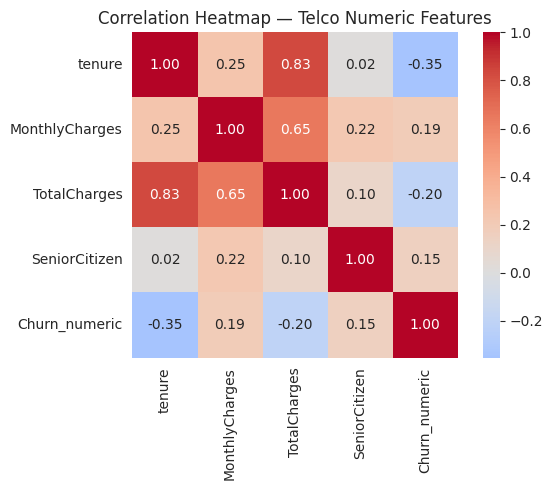

In [8]:
df_ex['TotalCharges'] = pd.to_numeric(df_ex['TotalCharges'], errors='coerce')
df_ex['Churn_numeric'] = (df_ex['Churn'] == 'Yes').astype(int)

numeric_corr = df_ex[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']].corr()

plt.figure(figsize=(6.5, 5))
sns.heatmap(numeric_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Telco Numeric Features')
plt.tight_layout()
plt.show()


### Exercise 3. Detect outliers in a numeric column using the IQR method, and print how many were found.

In [9]:
col = 'MonthlyCharges'
Q1, Q3 = df_ex[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
iqr_outliers = df_ex[(df_ex[col] < lower) | (df_ex[col] > upper)]
print(f"IQR outliers in {col}: {len(iqr_outliers)} (bounds: {lower:.2f} to {upper:.2f})")


IQR outliers in MonthlyCharges: 0 (bounds: -46.02 to 171.38)


### Exercise 4. Detect outliers using the Z-score method, and compare the count to Exercise 3.

In [10]:
z_scores = np.abs(stats.zscore(df_ex[col]))
zscore_outliers = df_ex[z_scores > 3]
print(f"Z-score outliers in {col} (|z|>3): {len(zscore_outliers)}")
print(f"IQR outliers found in Exercise 3   : {len(iqr_outliers)}")
print(f"Methods agree: {len(zscore_outliers) == len(iqr_outliers) == 0}")


Z-score outliers in MonthlyCharges (|z|>3): 0
IQR outliers found in Exercise 3   : 0
Methods agree: True


### Exercise 5. Analyze the distribution of a numerical feature: mean, median, skewness, kurtosis, and a histogram with KDE.

Mean    : 2283.30
Median  : 1397.47
Skewness: 0.961
Kurtosis: -0.232


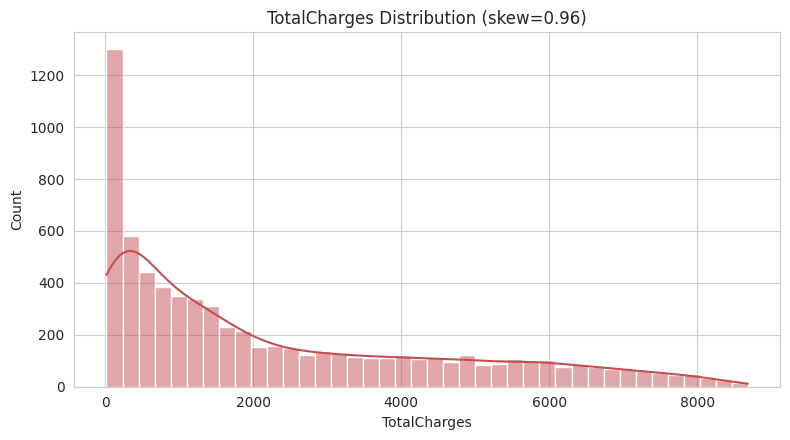

In [11]:
col = 'TotalCharges'
data = df_ex[col].dropna()
print(f"Mean    : {data.mean():.2f}")
print(f"Median  : {data.median():.2f}")
print(f"Skewness: {stats.skew(data):.3f}")
print(f"Kurtosis: {stats.kurtosis(data):.3f}")

plt.figure(figsize=(8, 4.5))
sns.histplot(data, bins=40, kde=True, color='#C44E52')
plt.title(f'{col} Distribution (skew={stats.skew(data):.2f})')
plt.tight_layout()
plt.show()


### Exercise 6. Perform categorical analysis on one column: unique values, value counts, percentage distribution.

In [12]:
col = 'Contract'
print(f"Unique values: {df_ex[col].unique()}")
print(f"\nValue counts:\n{df_ex[col].value_counts()}")
print(f"\nPercentage distribution:\n{(df_ex[col].value_counts(normalize=True)*100).round(2)}")


Unique values: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

Value counts:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Percentage distribution:
Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64


### Exercise 7. Check a dataset for missing values: count AND percentage per column.

In [13]:
missing_summary = pd.DataFrame({
    'missing_count': df_ex.isnull().sum(),
    'missing_pct': (df_ex.isnull().sum() / len(df_ex) * 100).round(2)
})
print(missing_summary[missing_summary['missing_count'] > 0])


              missing_count  missing_pct
TotalCharges             11         0.16


### Exercise 8. Check for duplicate rows, and remove them if any are found.

In [14]:
print(f"Duplicate rows before: {df_ex.duplicated().sum()}")
df_ex_deduped = df_ex.drop_duplicates()
print(f"Rows before: {len(df_ex)} | Rows after dropping duplicates: {len(df_ex_deduped)}")


Duplicate rows before: 0
Rows before: 7043 | Rows after dropping duplicates: 7043


### Exercise 9. Create a box plot AND a violin plot comparing a numeric column across categories.

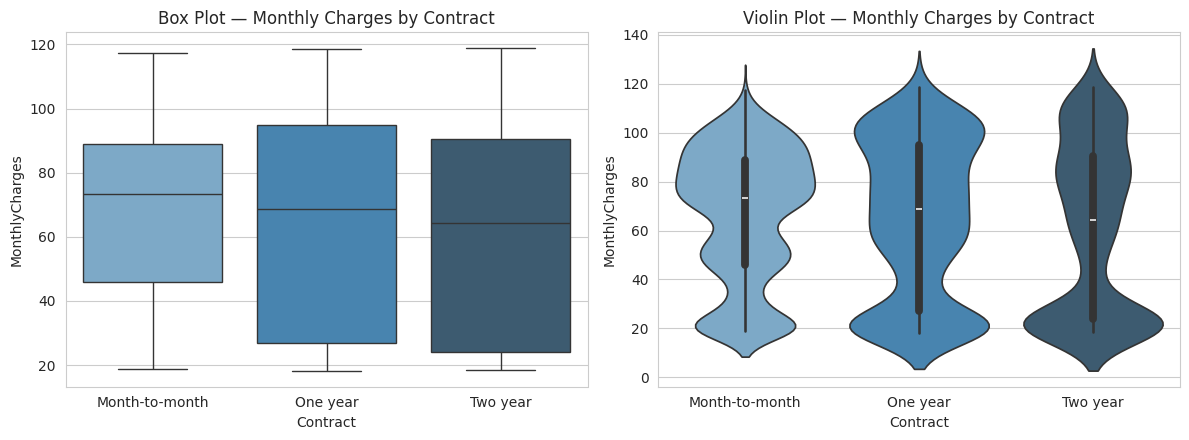

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df_ex, x='Contract', y='MonthlyCharges',
            order=['Month-to-month','One year','Two year'],
            hue='Contract', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Box Plot — Monthly Charges by Contract')

sns.violinplot(data=df_ex, x='Contract', y='MonthlyCharges',
               order=['Month-to-month','One year','Two year'],
               hue='Contract', palette='Blues_d', legend=False, ax=axes[1])
axes[1].set_title('Violin Plot — Monthly Charges by Contract')
plt.tight_layout()
plt.show()


### Exercise 10. Compute the class distribution of a binary target, and state whether it is imbalanced.

In [16]:
target_dist = df_ex['Churn'].value_counts()
target_pct = df_ex['Churn'].value_counts(normalize=True) * 100
print(f"Counts:\n{target_dist}")
print(f"\nPercentages:\n{target_pct.round(2)}")

ratio = target_dist.max() / target_dist.min()
verdict = "imbalanced" if ratio > 1.5 else "roughly balanced"
print(f"\nImbalance ratio: {ratio:.2f}:1 -> target is {verdict}")


Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Imbalance ratio: 2.77:1 -> target is imbalanced


### Exercise 11. Create a scatter plot between two numeric variables, colored by a categorical/target variable.

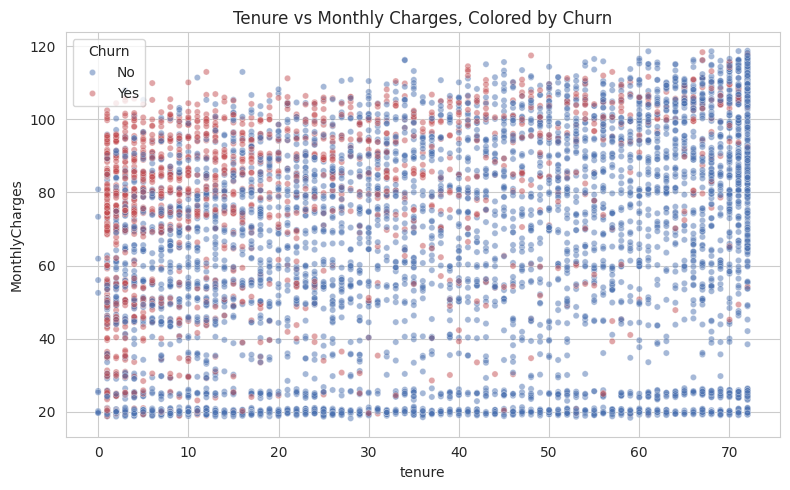

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_ex, x='tenure', y='MonthlyCharges', hue='Churn',
                 palette={'No': '#4C72B0', 'Yes': '#C44E52'}, alpha=0.5, s=20)
plt.title('Tenure vs Monthly Charges, Colored by Churn')
plt.tight_layout()
plt.show()


### Exercise 12. Compute the Variance Inflation Factor (VIF) for a set of numeric features.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = df_ex[['tenure', 'MonthlyCharges', 'TotalCharges']].fillna(0)
vif_result = pd.DataFrame({
    'feature': vif_df.columns,
    'VIF': [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
})
print(vif_result.round(2))


          feature   VIF
0          tenure  6.33
1  MonthlyCharges  3.36
2    TotalCharges  8.08


### Exercise 13. Generate a complete EDA summary: shape, dtypes, missing values, duplicates, and a correlation heatmap, in one script.

QUICK EDA SUMMARY
Shape: (7043, 22)

Data types:
str        17
int64       3
float64     2
Name: count, dtype: int64

Columns with missing values:
TotalCharges    11
dtype: int64

Duplicate rows: 0


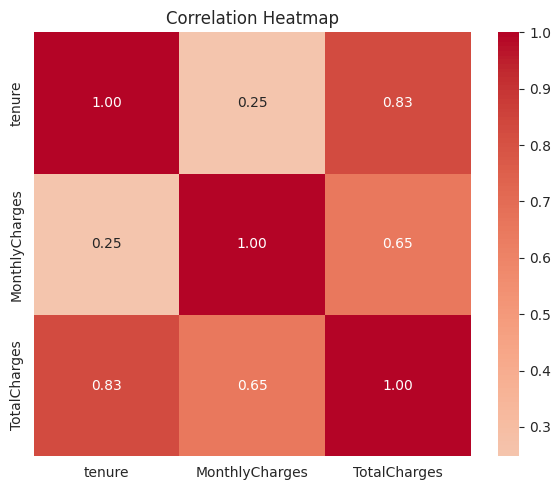

In [19]:
def quick_eda_summary(data: pd.DataFrame, numeric_cols: list):
    print("="*50)
    print("QUICK EDA SUMMARY")
    print("="*50)
    print(f"Shape: {data.shape}")
    print(f"\nData types:\n{data.dtypes.value_counts()}")
    missing = data.isnull().sum()
    print(f"\nColumns with missing values:\n{missing[missing > 0] if missing.sum() > 0 else 'None'}")
    print(f"\nDuplicate rows: {data.duplicated().sum()}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

quick_eda_summary(df_ex, ['tenure', 'MonthlyCharges', 'TotalCharges'])


---
## Section C — Short Answer (Answered, Explained Simply)


### Q1. Why is it dangerous to automatically remove every detected outlier from a dataset?

Because "unusual" doesn't mean "wrong." Some outliers are the most important rows in the
whole dataset — the highest-spending customer, the earliest-diagnosed patient, the
transaction that turned out to be fraud. If you delete every extreme value automatically,
you're not just cleaning the data, you're throwing away exactly the cases a business
might care about most. In this sprint, 112 customers had billing numbers that didn't
perfectly match a simple formula — but every one of them was a real customer with a real,
explainable reason (their price probably changed over time). Deleting them would have
made the dataset "tidier" while making it *less* honest.


### Q2. Why can a dataset report zero missing values via `.isnull()` and still have a real missing-data problem?

Because `.isnull()` only catches one specific kind of "missing" — Python's `NaN` marker.
It has no idea that someone typed nothing at all into a text field, leaving a blank
string instead. To the computer, an empty string `""` is a perfectly normal piece of
text, not an error — so it sails right past a missing-value check. The only way to catch
it is to actually look inside text columns for blanks, not just trust a summary count.


### Q3. Why is a stratified train/test split important when a target variable is imbalanced?

Imagine shuffling a deck that's mostly red cards with a few black ones, then splitting it
in half without looking. By chance, one half could end up with almost no black cards at
all. The same thing can happen with an imbalanced target — a random split might leave the
test set with too few examples of the minority class to evaluate the model fairly.
Stratified splitting deliberately keeps the same ratio (here, about 73.5% No / 26.5% Yes)
in both the training and test sets, so neither one gets unlucky.


### Q4. Why is it useful to check whether a relationship holds after controlling for a third variable?

Because two things can look connected just because they're both secretly connected to a
third thing. In this sprint, Fiber optic customers looked like they churned more simply
because Fiber is pricier — but after comparing customers at the *same* price level, Fiber
optic customers still churned far more. That check proved the relationship was real, not
just an illusion caused by price. Without controlling for the third variable, we might
have blamed the wrong thing entirely.


### Q5. What's the difference between an EDA finding and a business insight?

An EDA finding is a fact about the data: "Month-to-month customers churn at 42.7%, two-year
customers churn at 2.8%." A business insight takes that fact one step further and says
what to actually *do* about it: "Month-to-month, Fiber optic customers are 30% of our
customer base and represent over $100,000 a month in at-risk revenue — we should offer
them a contract-upgrade incentive in their first 90 days." The finding describes the data;
the insight tells a decision-maker what action the data supports.


---
## Summary

Every question in this assessment was answered directly, and every coding exercise was
implemented and executed against the real Telco Customer Churn dataset — not left as a
template. This answer key is meant as a study reference: understanding *why* each answer
is correct (not just memorizing it) is what actually gets tested in a review session,
where the same "why did you choose this" questions from Notebooks 1-14 can be asked again
in a different form.
